# Portfolio Project: Online Retail Exploratory Data Analysis with Python

## Case Study
In this project, I am going to work with transactional data from an online retail store. The dataset contains information about customer purchases, including product details, quantities, prices, and timestamps.

By conducting exploratory data analysis, I will identify patterns, outliers, and correlations in the data that allow me to make data-driven decisions and recommendations to optimize the store's operations and improve customer satisfaction. Through visualizations and statistical analysis, I will uncover key trends, such as the busiest sales months, best-selling products, and the store's most valuable customers.

## Project Objectives
1. Describe data to answer key questions to uncover insights
2. Gain valuable insights that will help improve online retail performance
3. Provide analytic insights and data-driven recommendations

## Dataset

The dataset contains transactional data of an online retail store from 2010 to 2011. The dataset is available as a .xlsx file named `Online Retail.xlsx`. It can be downloaded from [here](https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx).

The dataset contains the following columns:

- InvoiceNo: Invoice number of the transaction
- StockCode: Unique code of the product
- Description: Description of the product
- Quantity: Quantity of the product in the transaction
- InvoiceDate: Date and time of the transaction
- UnitPrice: Unit price of the product
- CustomerID: Unique identifier of the customer
- Country: Country where the transaction occurred

## Tasks

I will perform the following stpes:

1. Load the dataset into a Pandas DataFrame and display the first few rows to get an overview of the data.
2. Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns.
3. Explore the basic statistics of the dataset, including measures of central tendency and dispersion.
4. Perform data visualization to gain insights into the dataset. Generate appropriate plots, such as histograms, scatter plots, or bar plots, to visualize different aspects of the data.
5. Identify any outliers or anomalies in the dataset and discuss their potential impact on the analysis.
6. Analyze the sales trends over time. Identify the busiest months and days of the week in terms of sales.
7. Explore the top-selling products and countries based on the quantity sold.
8. Draw conclusions and summarize your findings from the exploratory data analysis.

## Task 1: Load the Data

In [72]:
# Importing required library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from IPython.display import Image, display
%matplotlib inline     
sns.set(color_codes=True)

In [73]:
# Loading the data
df=pd.read_excel("Online Retail.xlsx")

In [3]:
# First 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Last 5 rows of the data
df.tail(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## Task 2: Data Cleaning

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [81]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [82]:
# Removing rows with missing CustomerID
df=df.dropna(subset=["CustomerID"])

In [83]:
# Validating data 
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [84]:
# Drop invalid rows based on 'Quantity' and 'UnitPrice' column
df = df[(df["Quantity"] >0) & (df["UnitPrice"] >0)]

#### Unit Price and Quantity can not be 'zero' or less than 'zero'. So, I filter the Unit Price and Quantity column.

In [85]:
# Creating 'Sales' column for calculating Sales trend
df["Sales"]=df["Quantity"]*df["UnitPrice"]

#### There is no 'Sales' column so I add this column multiplying the 'UnitPrice' and 'Quantity' column.

In [86]:
# Extracting date, month and days
df["Date"]=df["InvoiceDate"].dt.date
df["Month"] = df["InvoiceDate"].dt.month_name()
df["Days"] = df["InvoiceDate"].dt.day_name()

In [87]:
df=df.set_index("InvoiceDate")
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Sales,Date,Month,Days
InvoiceDate,,,,,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30,2010-12-01,December,Wednesday
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,2010-12-01,December,Wednesday
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00,2010-12-01,December,Wednesday
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34,2010-12-01,December,Wednesday
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34,2010-12-01,December,Wednesday


## Task 3: Descriptive Statistics

I use 'describe()' function to observe the basic statistics of the 'Quantity','UnitPrice' and 'Sales'. Using this function, we can see the mean, median, standard deviation and so on.

In [88]:
df[["Quantity", "UnitPrice","Sales"]].describe()

,Quantity,UnitPrice,Sales
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


The maximum values of these column are so high that affect the mean and standard deviation.

In [89]:
# Skewness values
df[["Quantity", "UnitPrice","Sales"]].skew()

Quantity     409.892972
UnitPrice    204.032727
Sales        451.443182
dtype: float64

The skewness values of 'Quantity','UnitPrice' and 'Sales' are extremly high and positive. There distribution are heavily right-skewd. Most value are small and a few values are extremly large. That means, this data contain some extreme outliers.

## Task 4: Data visualization

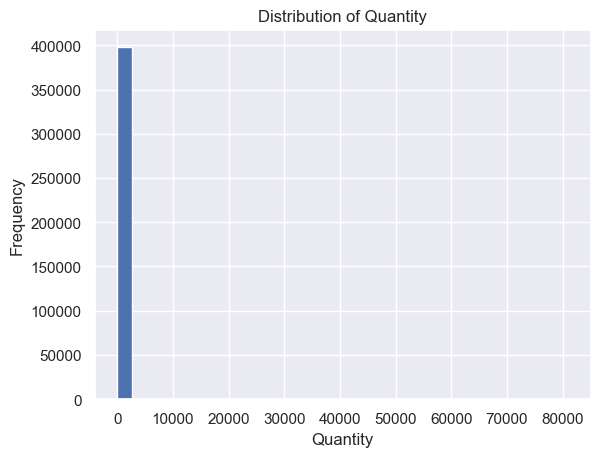

In [90]:
# Histogram of 'Quantity'

plt.hist(df["Quantity"], bins=30)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.show()


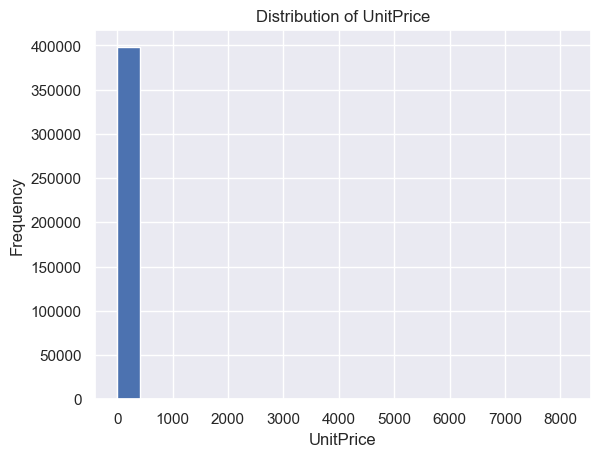

In [91]:
# Distribution of 'UnitPrice'
plt.hist(df["UnitPrice"],bins=20)
plt.xlabel("UnitPrice")
plt.ylabel("Frequency")
plt.title("Distribution of UnitPrice")
plt.show()

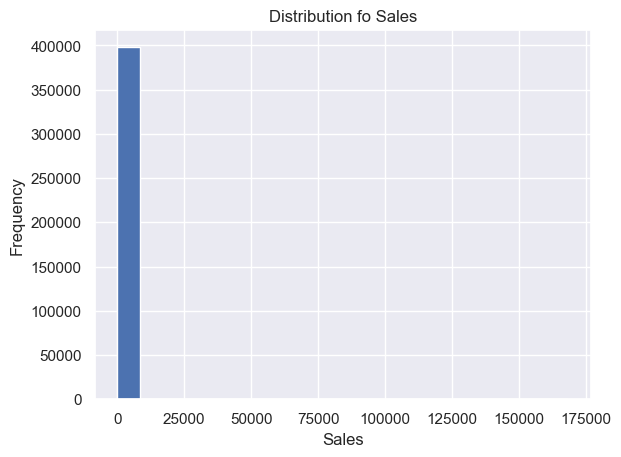

In [92]:
# Histogram of Sales
plt.hist(df["Sales"],bins=20)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution fo Sales")
plt.show()

#### The Quantity and UnitPrice columns contain extreme values so the visualization looks like that. Sales correlated with these column, so these extreme values affect on Sales.

### Scatter plot between Sales and Quantity

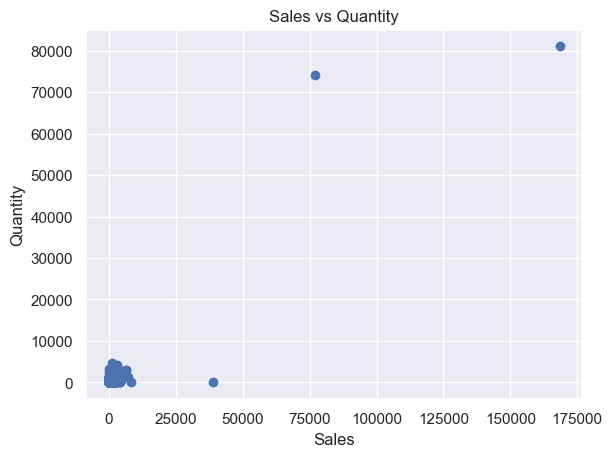

In [93]:
plt.scatter(df["Sales"], df["Quantity"])
plt.xlabel("Sales")
plt.ylabel("Quantity")
plt.title("Sales vs Quantity")
plt.show()


### Top 10 Customer based on quantity purchased 

In [94]:
top_customers = df.groupby("CustomerID")["Quantity"].sum().nlargest(10) 
top_customers

CustomerID
14646.0    196915
16446.0     80997
14911.0     80265
12415.0     77374
12346.0     74215
17450.0     69993
17511.0     64549
18102.0     64124
13694.0     63312
14298.0     58343
Name: Quantity, dtype: int64

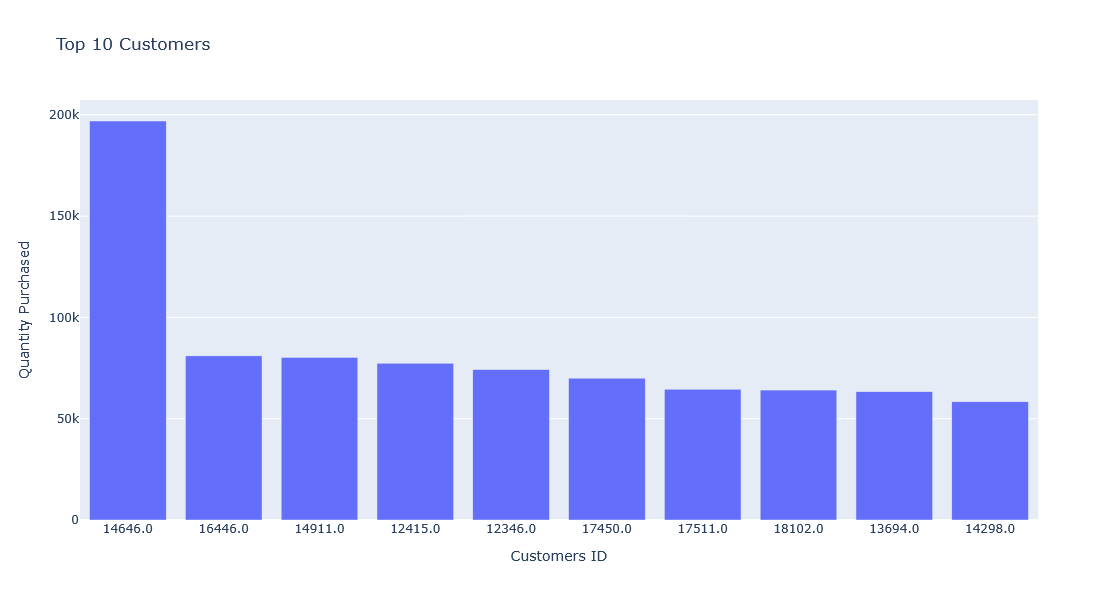

In [95]:

fig = px.bar(
    x=top_customers.index.astype(str),
    y=top_customers.values,
    labels={'x': 'Customers ID', 'y': 'Quantity Purchased'},
    title='Top 10 Customers'
)
fig.update_layout(
    autosize=False,
    width=900,    # pixels
    height=600    # pixels
)

fig.show()


## Task 5: Identify outliers and removing them

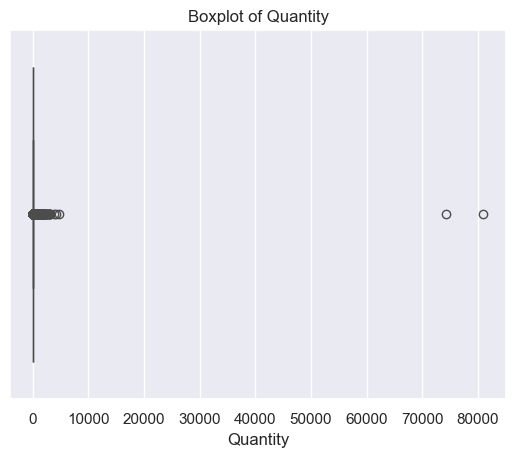

In [96]:
# Visualize outliers using boxplot
sns.boxplot(x=df['Quantity'])
plt.title("Boxplot of Quantity")
plt.show()

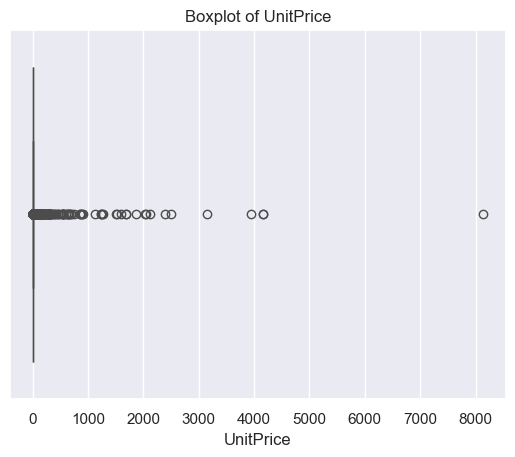

In [97]:
#Boxplot of UnitPrice
sns.boxplot(x=df['UnitPrice'])
plt.title("Boxplot of UnitPrice")
plt.show()

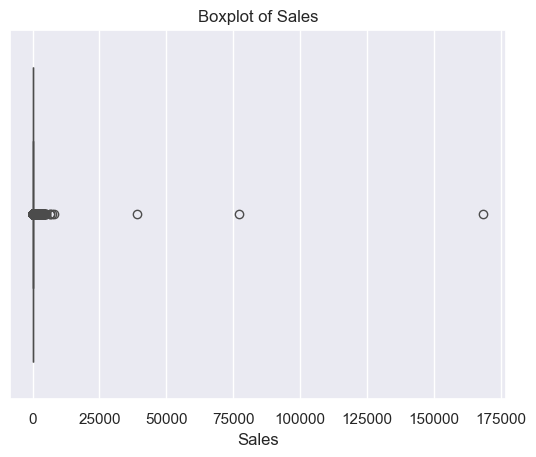

In [98]:
#Boxplot of Sales
sns.boxplot(x=df['Sales'])
plt.title("Boxplot of Sales")
plt.show()

From the boxplot visualization, we can clearly seen that there are outliers in the 'Quantity', 'UnitPrice' and 'Sales' column of the dataset.Now, I am going to remove these outliers and again do boxplot. I will use IQR method to remove the outliers.

In [99]:
cols = ["Quantity", "UnitPrice","Sales"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]


In [100]:
# After removing outliers
df[['Quantity','UnitPrice','Sales']].describe()

,Quantity,UnitPrice,Sales
count,324716.000000,324716.000000,324716.000000
mean,7.070970,2.123759,10.854211
std,6.486069,1.500057,8.235695
min,1.000000,0.001000,0.001000
25%,2.000000,0.950000,3.750000
50%,5.000000,1.650000,9.900000
75%,12.000000,2.950000,16.500000
max,27.000000,7.500000,37.700000


In [101]:
df[["Quantity", "UnitPrice","Sales"]].skew()

Quantity     1.311922
UnitPrice    1.122088
Sales        0.807376
dtype: float64

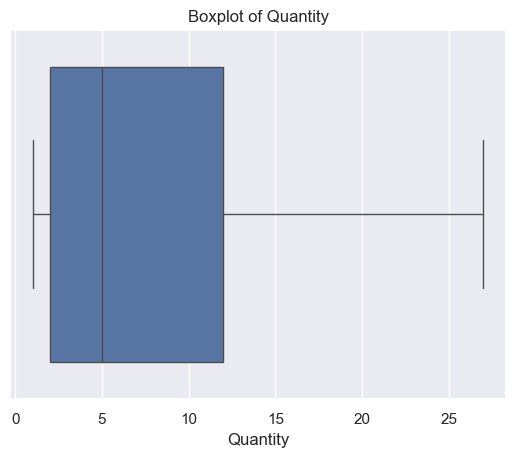

In [102]:
# Visualize after removing outliers using boxplot
sns.boxplot(x=df['Quantity'])
plt.title("Boxplot of Quantity")
plt.show()

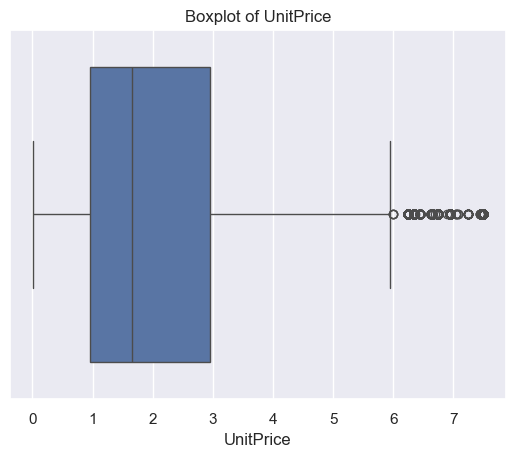

In [103]:
sns.boxplot(x=df['UnitPrice'])
plt.title('Boxplot of UnitPrice')
plt.show()

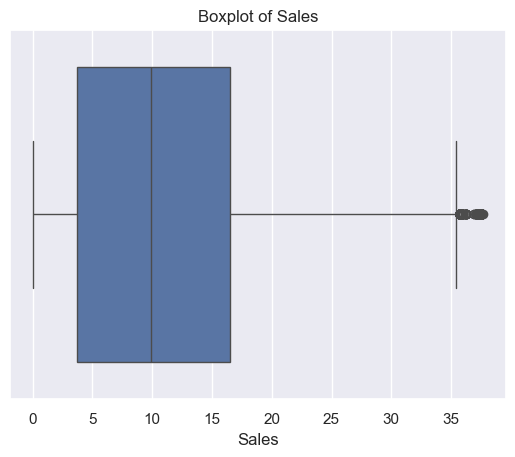

In [104]:
#After removing outliers Boxplot of Sales
sns.boxplot(x=df['Sales'])
plt.title("Boxplot of Sales")
plt.show()

### Impact of Outliers:
Outliers affect a model.
Outliers lead the decision to a wrong way. Before removing outliers,we see that the histogram, boxplot and scatterplot show unusual visualization

# Task 6: Analyze the sales trends over time

### Daily Sales Trend

In [105]:
daily_sales = df.groupby("Date")["Sales"].sum().reset_index()

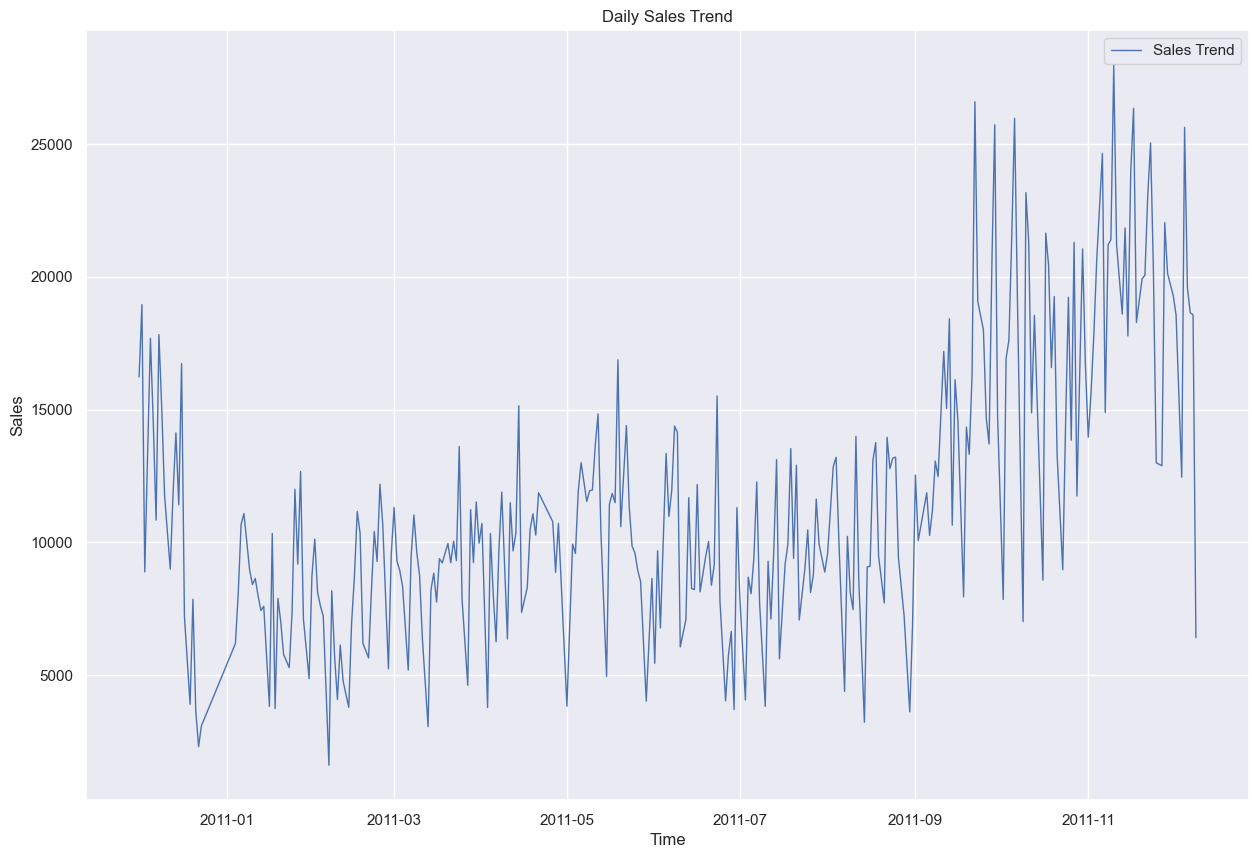

In [106]:
#After Removing outliers Daily sales trend
daily_sales.plot(x='Date',y='Sales',label="Sales Trend",figsize=(15,10),linewidth=1)
plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Daily Sales Trend")

plt.show()

### Monthly Sales Trend

In [107]:
monthly_sales = df["Sales"].resample("ME").sum()
monthly_sales.index = monthly_sales.index.strftime("%b %Y")

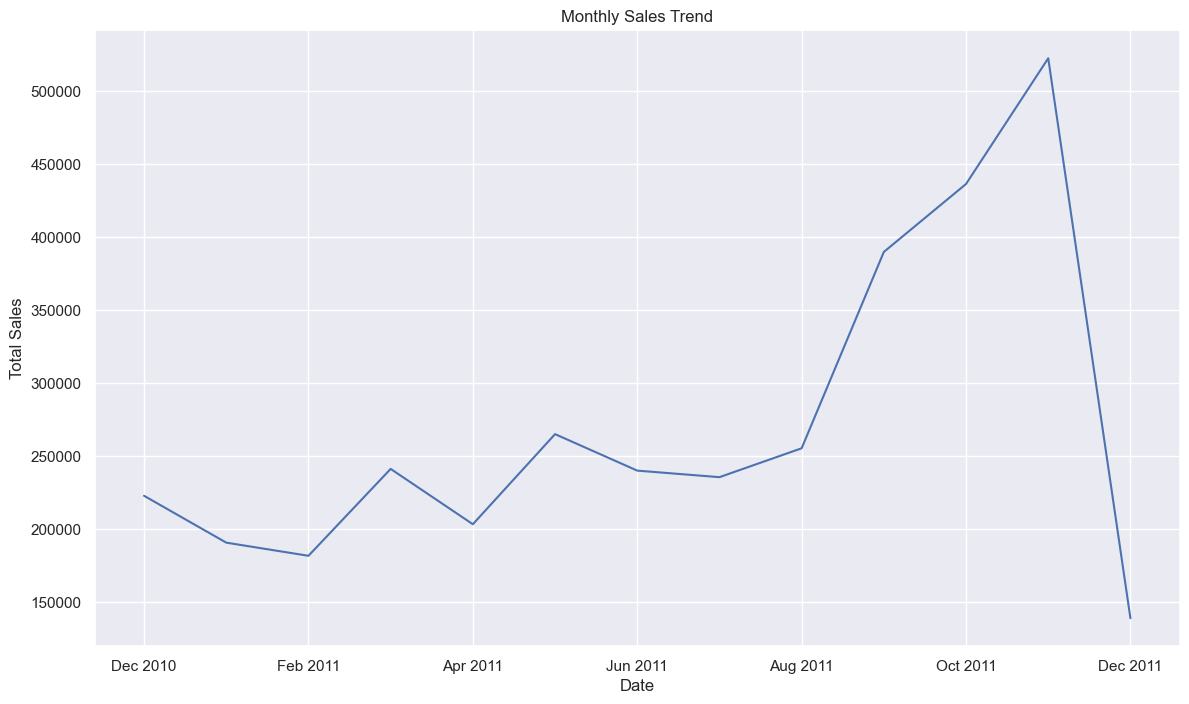

In [108]:
monthly_sales.plot(figsize=(14,8))
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Date")
plt.show()


### Identifying the busiest months and days of the week in terms of sales.

#### Busiest Month

In [109]:
busiest_month = monthly_sales.idxmax()
max_sales = monthly_sales.max()

print(f"Busiest Month: {busiest_month}")
print(f"Total sales  : {max_sales}")

Busiest Month: Nov 2011
Total sales  : 522314.3


#### We can see that the highest sales occur on November, 2011. That is 522314.3 

#### Visualization

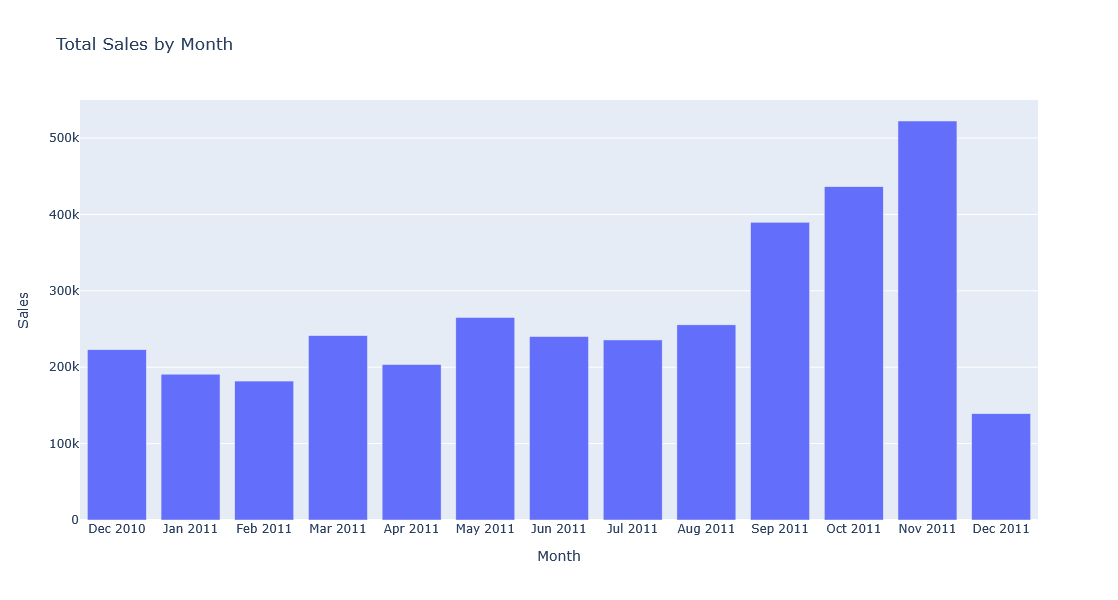

In [110]:
fig = px.bar(
    x=monthly_sales.index,
    y=monthly_sales.values,
    labels={'x': 'Month', 'y': 'Sales'},
    title='Total Sales by Month'
)
fig.update_layout(
    autosize=False,
    width=1000,    # pixels
    height=600   
)

fig.show()


#### Busiest Day of Week

In [111]:
sales_by_day= df.groupby("Days")["Sales"].sum()
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

sales_by_day = sales_by_day.reindex(day_order)


In [112]:
busiest_day = sales_by_day.idxmax()
max_sales = sales_by_day.max()

print(f"Busiest day: {busiest_day}")
print(f"Total sales: {max_sales}")


Busiest day: Thursday
Total sales: 754860.65


#### Visualization

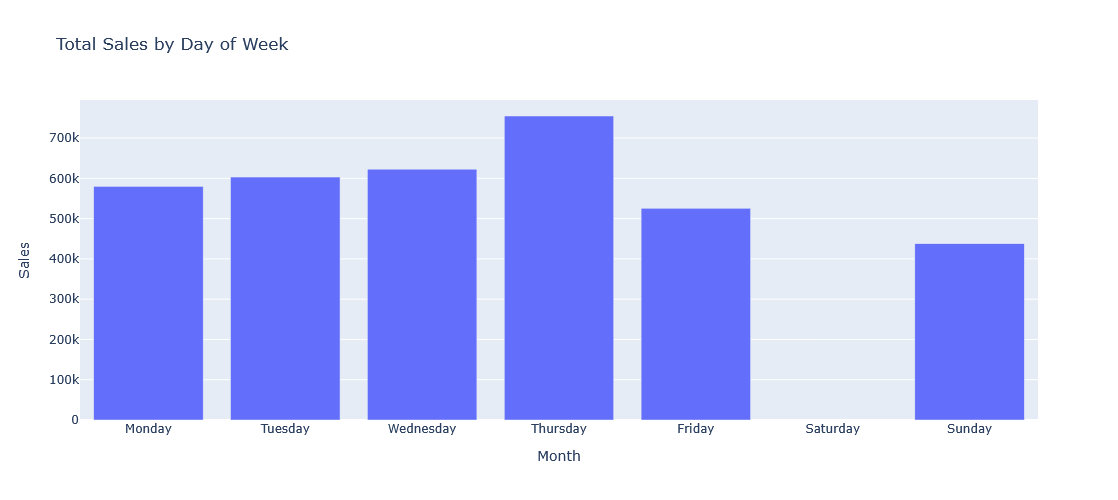

In [113]:
fig = px.bar(
    x=sales_by_day.index,
    y=sales_by_day.values,
    labels={'x': 'Month', 'y': 'Sales'},
    title='Total Sales by Day of Week'
)
fig.update_layout(
    autosize=False,
    width=900,    # pixels
    height=500   
)

fig.show()


# Task 7: Top-selling products and Countries based on the quantity sold

### Top selling Products

In [114]:
# Top selling Products
top_products=df.groupby('Description')['Quantity'].sum().nlargest(10)
top_products

Description
PACK OF 72 RETROSPOT CAKE CASES       15009
ASSORTED COLOUR BIRD ORNAMENT         10307
LUNCH BAG RED RETROSPOT                9676
WHITE HANGING HEART T-LIGHT HOLDER     9059
JAM MAKING SET PRINTED                 8618
PACK OF 60 PINK PAISLEY CAKE CASES     8532
JUMBO BAG RED RETROSPOT                8500
60 TEATIME FAIRY CAKE CASES            8401
RED RETROSPOT WRAP                     7472
LUNCH BAG  BLACK SKULL.                7349
Name: Quantity, dtype: int64

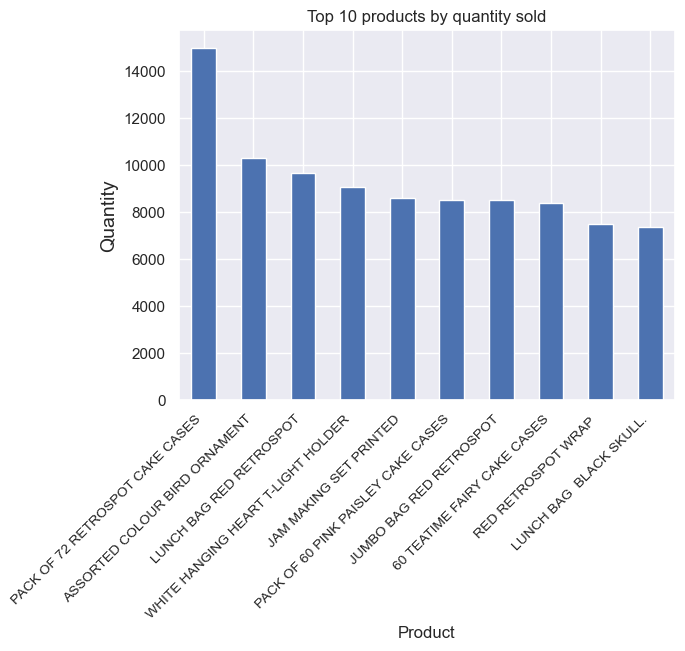

In [115]:
top_products.plot(kind='bar')
plt.xlabel("Product",fontsize=12)
plt.ylabel("Quantity",fontsize=14)
plt.title("Top 10 products by quantity sold")
plt.xticks(rotation=45,horizontalalignment='right',fontsize=10)
plt.show()

### Top selling countries

In [116]:
# Top selling countries
top_countries=(df[['Country','Quantity']].groupby('Country')['Quantity'].sum().nlargest(10))
top_countries

Country
United Kingdom     1974450
Germany              76188
France               68108
EIRE                 52724
Spain                17536
Belgium              17184
Switzerland          15727
Portugal             11087
Norway                7601
Channel Islands       5917
Name: Quantity, dtype: int64

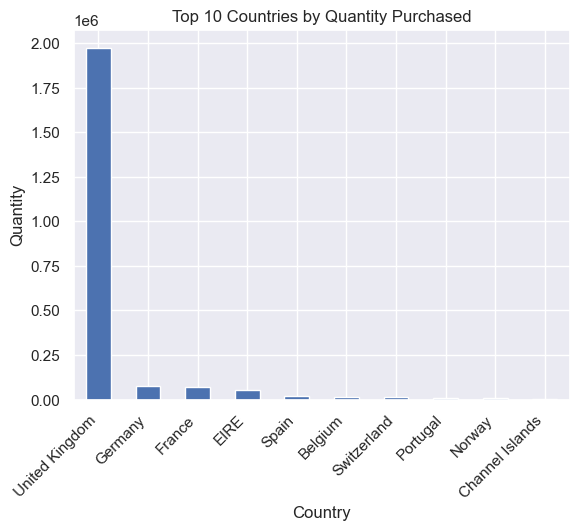

In [117]:
top_countries.plot(kind='bar')
#plt.bar(top_countries.index,top_countries['Quantity'])
plt.title("Top 10 Countries by Quantity Purchased")
plt.xlabel("Country")
plt.ylabel("Quantity")
plt.xticks(rotation=45,horizontalalignment='right')
plt.show()

# Task 8: Conclusions

<h4>We cleaned the data, studied overall sales behavior, identified when and where sales peak, found top-performing products and countries, and ensured extreme values don’t mislead business decisions.</h4>

<h4> Key insights: </h4>

* Sales are highly right-skewed, indicating a small number of high-value transactions.

* The data is not enough for monthly seasonality check because of short-lenght just 1 year and one month.

* The highest transaction occur On November, 2011 .

* Sales are highest on Thursday .

* Product "PACK OF 72 RETROSPOT CAKE CASES" has highest sales volume .

* UK dominates sales volume compared to other countries .

* Outliers reflect bulk orders and should be treated cautiously .